In [38]:
import pandas as pd

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
dataset = pd.read_csv("loan_approval_data.csv")
dataset = dataset.dropna()

dataset.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
5,6.0,8265.0,4831.0,Salaried,53.0,Single,1.0,602.0,1.0,0.56,19522.0,2911.0,9798.0,36.0,Home,Semiurban,Graduate,Male,Unemployed,No
6,7.0,18850.0,2768.0,Salaried,58.0,Married,0.0,687.0,0.0,0.48,14635.0,8991.0,26143.0,24.0,Home,Rural,Graduate,Male,Private,No
10,11.0,18023.0,4033.0,Salaried,52.0,Married,2.0,688.0,1.0,0.13,18244.0,40004.0,10415.0,12.0,Education,Urban,Not Graduate,Female,MNC,Yes


In [40]:
X = dataset.drop(columns=["Loan_Approved", "Applicant_ID"])
y = dataset["Loan_Approved"]

X = pd.get_dummies(
    X,
    columns=[
        "Employment_Status",
        "Employer_Category",
        "Marital_Status",
        "Loan_Purpose",
        "Property_Area",
        "Education_Level",
        "Gender"
    ],
    drop_first=True,
    dtype=int
)

y = y.map({"Yes":1, "No":0})
# X["smoker"] = X["smoker"].map({"yes":1, "no":0})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
# knn

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors":[3,5,7,9,11,13,15,21,25,29]
}

classifierCV_model = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
)

classifierCV_model.fit(X_train, y_train)
y_pred = classifierCV_model.predict(X_test)

res = pd.DataFrame(classifierCV_model.cv_results_)
print(res[["param_knn__n_neighbors", "mean_test_score"]])

print(classifierCV_model.best_params_)

   param_knn__n_neighbors  mean_test_score
0                       3         0.685714
1                       5         0.710714
2                       7         0.714286
3                       9         0.760714
4                      11         0.746429
5                      13         0.750000
6                      15         0.735714
7                      21         0.750000
8                      25         0.725000
9                      29         0.728571
{'knn__n_neighbors': 9}


In [42]:
print("Results achieved from Knn")
print("accuracy_score", accuracy_score(y_test, y_pred))
print("precision_score", precision_score(y_test, y_pred))
print("recall_score", recall_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("confusion_matrix", confusion_matrix(y_test, y_pred))

Results achieved from Knn
accuracy_score 0.7464788732394366
precision_score 0.6923076923076923
recall_score 0.391304347826087
f1_score 0.5
confusion_matrix [[44  4]
 [14  9]]


In [43]:
# Logistic Regression

Logistic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

Logistic_model.fit(X_train, y_train)
y_pred_Logistic = Logistic_model.predict(X_test)

In [44]:
print("Results achieved from Logistic Regression")
print("accuracy_score", accuracy_score(y_test, y_pred_Logistic))
print("precision_score", precision_score(y_test, y_pred_Logistic))
print("recall_score", recall_score(y_test, y_pred_Logistic))
print("f1_score", f1_score(y_test, y_pred_Logistic))
print("confusion_matrix", confusion_matrix(y_test, y_pred_Logistic))

Results achieved from Logistic Regression
accuracy_score 0.8028169014084507
precision_score 0.7142857142857143
recall_score 0.6521739130434783
f1_score 0.6818181818181818
confusion_matrix [[42  6]
 [ 8 15]]


In [45]:
# Naive Bayes

Bayes_model = GaussianNB()

Bayes_model.fit(X_train, y_train)
y_pred_bayes = Bayes_model.predict(X_test)

In [46]:
print("Results achieved from Naive Bayes")
print("accuracy_score", accuracy_score(y_test, y_pred_bayes))
print("precision_score", precision_score(y_test, y_pred_bayes))
print("recall_score", recall_score(y_test, y_pred_bayes))
print("f1_score", f1_score(y_test, y_pred_bayes))
print("confusion_matrix", confusion_matrix(y_test, y_pred_bayes))

Results achieved from Naive Bayes
accuracy_score 0.7183098591549296
precision_score 0.56
recall_score 0.6086956521739131
f1_score 0.5833333333333334
confusion_matrix [[37 11]
 [ 9 14]]


[Text(0, 0, '245'), Text(0, 0, '106')]

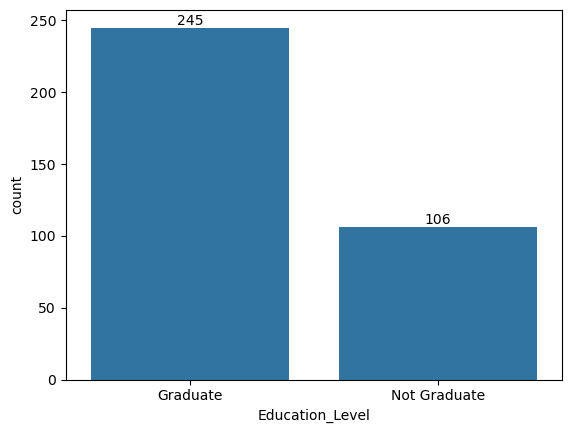

In [47]:
edu_cnt=dataset["Education_Level"].value_counts()
ax=sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

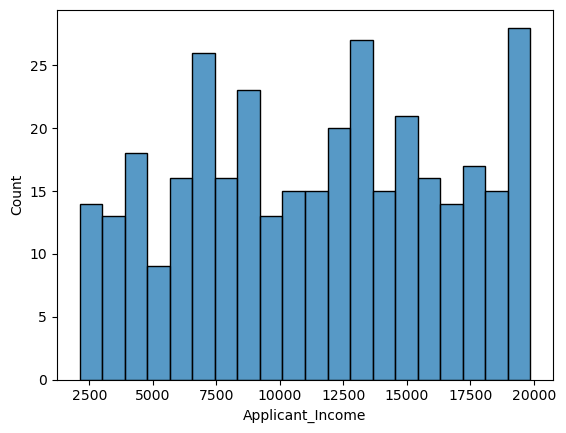

In [48]:
sns.histplot(
    data=dataset,
    x= "Applicant_Income",
    bins=20
)

In [49]:
dataset.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
5,6.0,8265.0,4831.0,Salaried,53.0,Single,1.0,602.0,1.0,0.56,19522.0,2911.0,9798.0,36.0,Home,Semiurban,Graduate,Male,Unemployed,No
6,7.0,18850.0,2768.0,Salaried,58.0,Married,0.0,687.0,0.0,0.48,14635.0,8991.0,26143.0,24.0,Home,Rural,Graduate,Male,Private,No
10,11.0,18023.0,4033.0,Salaried,52.0,Married,2.0,688.0,1.0,0.13,18244.0,40004.0,10415.0,12.0,Education,Urban,Not Graduate,Female,MNC,Yes


<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

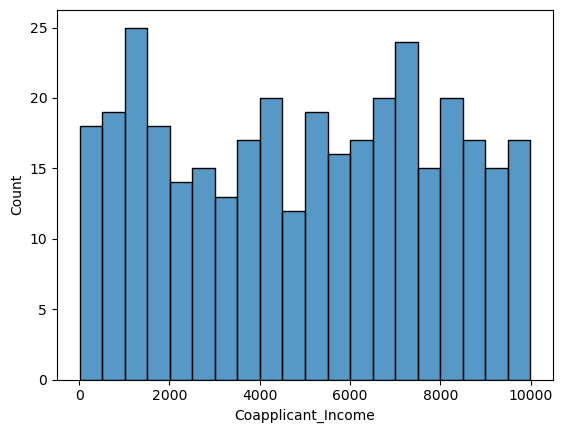

In [50]:
sns.histplot(
    data= dataset,
    x = "Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

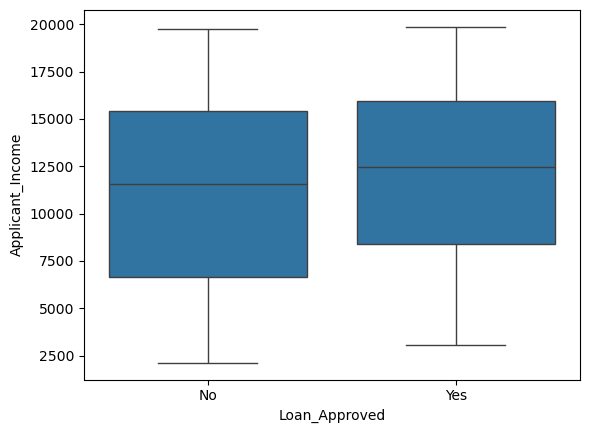

In [51]:
sns.boxplot(
    data= dataset,
    x = "Loan_Approved",
    y="Applicant_Income"
)

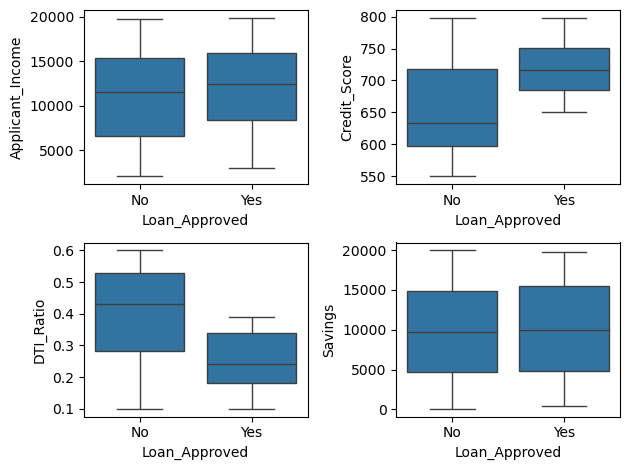

In [53]:
fig, axes =plt.subplots(2,2)

sns.boxplot(ax=axes[0,0], data= dataset, x= "Loan_Approved", y ="Applicant_Income")
sns.boxplot(ax=axes[0,1], data= dataset, x= "Loan_Approved", y ="Credit_Score")
sns.boxplot(ax=axes[1,0], data= dataset, x= "Loan_Approved", y ="DTI_Ratio")
sns.boxplot(ax=axes[1,1], data= dataset, x= "Loan_Approved", y ="Savings")

fig.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

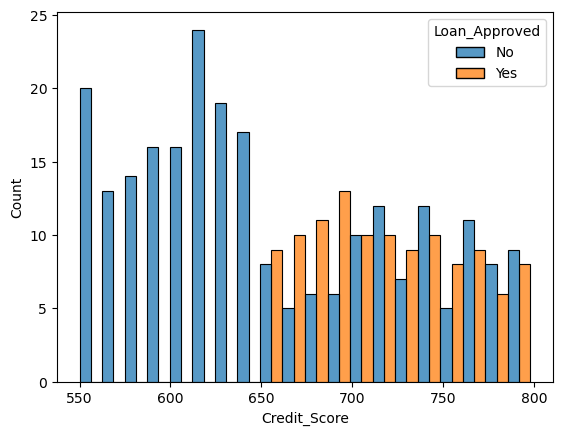

In [55]:
sns.histplot(
    data= dataset,
    x= "Credit_Score",
    hue= "Loan_Approved",
    bins= 20,
    multiple= "dodge"
    
)

<Axes: >

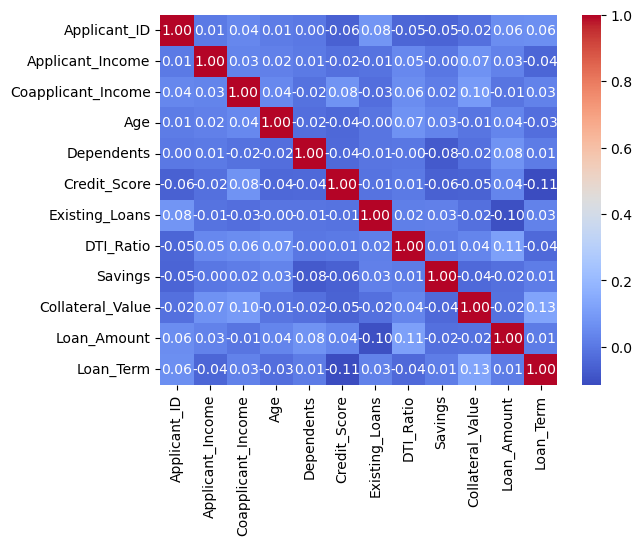

In [60]:
nums_col= dataset.select_dtypes(include= "number")
corr_matrix= nums_col.corr()

sns.heatmap(corr_matrix,
           annot= True,
            fmt= ".2f",
            cmap= "coolwarm"
           )